## 1. Class Distribution

- Shows the number of genuine and fraudulent transactions in the test dataset.
- Helps us understand the class imbalance before evaluation.
- The distribution is also visualized using a graph.

,Class,Count
0,Genuine,97904
1,Fraud,1983


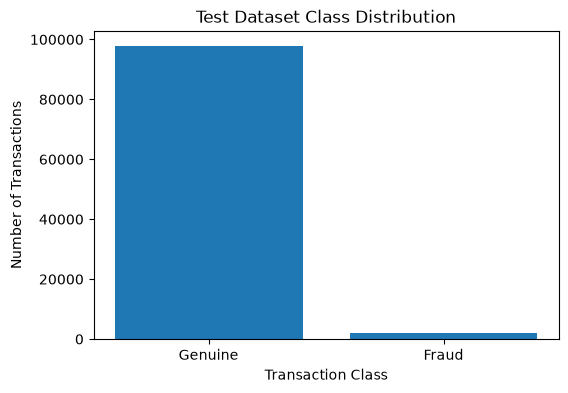

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the test dataset
test_data = pd.read_csv("data/transactions_test.csv")

# Count genuine and fraudulent transactions
class_counts = test_data["is_fraud"].value_counts()

genuine_count = class_counts.get(0, 0)
fraud_count = class_counts.get(1, 0)

# Display class distribution
distribution = pd.DataFrame({
    "Class": ["Genuine", "Fraud"],
    "Count": [genuine_count, fraud_count]
})

display(distribution)

# Visualize class distribution
plt.figure(figsize=(6, 4))
plt.bar(distribution["Class"], distribution["Count"])
plt.title("Test Dataset Class Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.show()

## 2. Model Testing on Unseen Data

- The trained model is tested on the unseen test dataset.
- Reconstruction error is calculated for each transaction.
- The calibrated threshold is used to classify transactions as normal or anomalous.

In [8]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model

# Load the trained model, preprocessor, and threshold
model = load_model("zero_day_autoencoder.keras")

preprocessor_data = joblib.load("preprocessor.joblib")
preprocessor = preprocessor_data["preprocessor"]

threshold_data = joblib.load("threshold.joblib")
threshold = threshold_data["threshold"]

# Load unseen test dataset
test_data = pd.read_csv("data/transactions_test.csv")

# Actual labels
y_true = test_data["is_fraud"].values

# Create a copy for preprocessing
X_test = test_data.drop(
    columns=["is_fraud", "transaction_id", "customer_id", "merchant_id"],
    errors="ignore"
)

# Create time-based features used during training
X_test["transaction_time"] = pd.to_datetime(X_test["transaction_time"])

X_test["transaction_hour"] = X_test["transaction_time"].dt.hour

X_test["transaction_day_of_week"] = X_test["transaction_time"].dt.dayofweek

X_test["is_weekend"] = (
    X_test["transaction_day_of_week"] >= 5
).astype(int)

# Apply the same preprocessing used during training
X_test_processed = preprocessor.transform(X_test)

# Generate reconstructed values
X_reconstructed = model.predict(
    X_test_processed,
    verbose=0
)

# Calculate reconstruction error
reconstruction_errors = np.mean(
    np.square(X_test_processed - X_reconstructed),
    axis=1
)

# Classify using the calibrated threshold
y_pred = (reconstruction_errors > threshold).astype(int)

print("Model testing completed successfully.")
print(f"Test samples      : {len(y_true):,}")
print(f"Threshold          : {threshold:.4f}")
print(f"Anomalies detected : {y_pred.sum():,}")

Model testing completed successfully.
Test samples      : 99,887
Threshold          : 1.0347
Anomalies detected : 2,871


## 3. Confusion Matrix

- Shows the correct and incorrect predictions made by the model.
- Helps identify True Positive, True Negative, False Positive, and False Negative cases.
- The results are visualized using a confusion matrix.

Confusion Matrix:
[[96934   970]
 [   82  1901]]


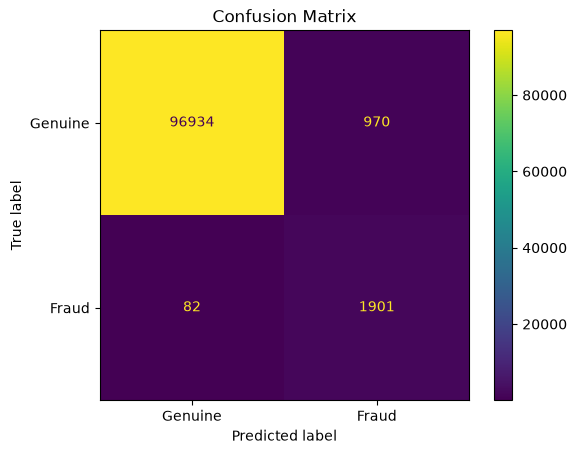

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display values
print("Confusion Matrix:")
print(cm)

# Visualize confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Fraud"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## 4. Classification Report

- Shows precision, recall, F1-score, and support for each class.
- Helps us evaluate the model's classification performance.
- The results are displayed in a table.

In [10]:
from sklearn.metrics import classification_report
import pandas as pd

# Generate classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=["Genuine", "Fraud"],
    output_dict=True
)

# Convert report into a table
report_df = pd.DataFrame(report).transpose()

# Display the classification report
display(report_df.round(4))

,precision,recall,f1-score,support
Genuine,0.9992,0.9901,0.9946,97904.0000
Fraud,0.6621,0.9586,0.7833,1983.0000
accuracy,0.9895,0.9895,0.9895,0.9895
macro avg,0.8306,0.9744,0.8889,99887.0000
weighted avg,0.9925,0.9895,0.9904,99887.0000


## 5. ROC Curve and ROC-AUC

- Shows model performance at different classification thresholds.
- ROC-AUC measures how well the model separates genuine and fraudulent transactions.
- The ROC curve is visualized using the reconstruction error.

ROC-AUC Score: 0.9980


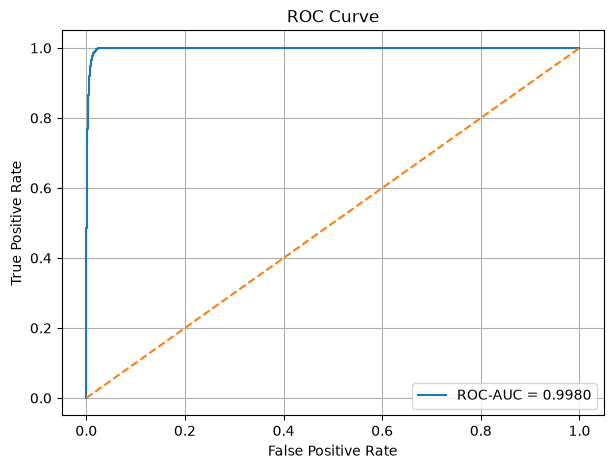

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC-AUC using reconstruction errors
roc_auc = roc_auc_score(y_true, reconstruction_errors)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    y_true,
    reconstruction_errors
)

# Display ROC-AUC
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

## 6. Reconstruction Error Distribution

- Shows the reconstruction error for genuine and fraudulent transactions.
- Helps us understand how the Autoencoder separates normal and anomalous transactions.
- The calibrated threshold is shown on the graph.

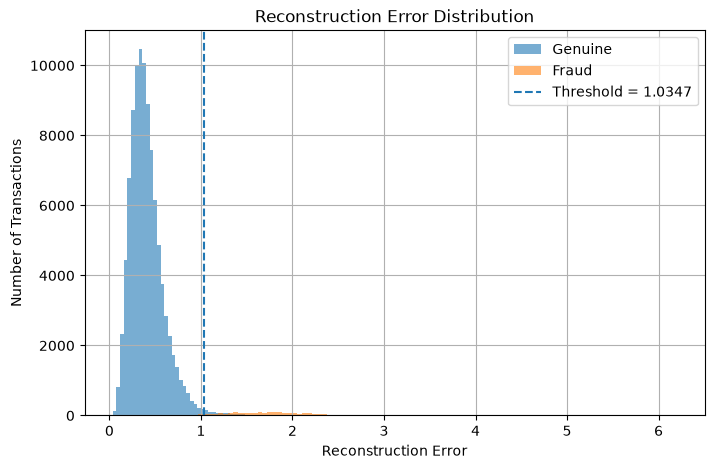

In [12]:
import matplotlib.pyplot as plt

# Separate reconstruction errors by class
genuine_errors = reconstruction_errors[y_true == 0]
fraud_errors = reconstruction_errors[y_true == 1]

# Plot reconstruction error distribution
plt.figure(figsize=(8, 5))

plt.hist(
    genuine_errors,
    bins=100,
    alpha=0.6,
    label="Genuine"
)

plt.hist(
    fraud_errors,
    bins=100,
    alpha=0.6,
    label="Fraud"
)

# Show calibrated threshold
plt.axvline(
    threshold,
    linestyle="--",
    label=f"Threshold = {threshold:.4f}"
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Transactions")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.grid()
plt.show()

## 7. Final Evaluation Summary

- Summarizes the overall performance of the trained model.
- Includes the main evaluation metrics and confusion matrix values.
- Provides a complete view of the model's performance on unseen data.

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate final evaluation metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Get confusion matrix values
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

# Create final summary
summary = pd.DataFrame({
    "Metric": [
        "Test Samples",
        "Genuine Transactions",
        "Fraud Transactions",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Threshold",
        "True Positive (TP)",
        "True Negative (TN)",
        "False Positive (FP)",
        "False Negative (FN)"
    ],
    "Value": [
        len(y_true),
        (y_true == 0).sum(),
        (y_true == 1).sum(),
        f"{accuracy:.4%}",
        f"{precision:.4%}",
        f"{recall:.4%}",
        f"{f1:.4%}",
        f"{roc_auc:.4f}",
        f"{threshold:.4f}",
        tp,
        tn,
        fp,
        fn
    ]
})

display(summary)

,Metric,Value
0,Test Samples,99887
1,Genuine Transactions,97904
2,Fraud Transactions,1983
3,Accuracy,98.9468%
4,Precision,66.2139%
5,Recall,95.8649%
6,F1-Score,78.3272%
7,ROC-AUC,0.9980
8,Threshold,1.0347
9,True Positive (TP),1901
